In [2]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import re

Import Libraries and Load Data

In [ ]:
# Load the dataset
df = pd.read_csv('Shakespeare_data.csv')

# Display basic info
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.columns)

Dataset shape: (111396, 6)
   Dataline      Play  PlayerLinenumber ActSceneLine         Player  \
0         1  Henry IV               NaN          NaN            NaN   
1         2  Henry IV               NaN          NaN            NaN   
2         3  Henry IV               NaN          NaN            NaN   
3         4  Henry IV               1.0        1.1.1  KING HENRY IV   
4         5  Henry IV               1.0        1.1.2  KING HENRY IV   

                                          PlayerLine  
0                                              ACT I  
1                       SCENE I. London. The palace.  
2  Enter KING HENRY, LORD JOHN OF LANCASTER, the ...  
3             So shaken as we are, so wan with care,  
4         Find we a time for frighted peace to pant,  
Index(['Dataline', 'Play', 'PlayerLinenumber', 'ActSceneLine', 'Player',
       'PlayerLine'],
      dtype='object')


Data Cleaning and Preprocessing

In [ ]:
# Clean and normalize text by removing unwanted characters, lowercasing and trimming whitespace
def clean_text(text):
    """Clean and normalize text"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s\.,!?;:\'\-]', '', text)
    text = ' '.join(text.split())
    return text

# Extract and clean player lines
lines = df['PlayerLine'].dropna().tolist()

cleaned_lines = [clean_text(line) for line in lines if clean_text(line)]

print(f"\nTotal lines: {len(cleaned_lines)}")
print(f"Sample lines:")
for i in range(5):
    print(f"  {cleaned_lines[i]}")


Total lines: 111396
Sample lines:
  act i
  scene i. london. the palace.
  enter king henry, lord john of lancaster, the earl of westmoreland, sir walter blunt, and others
  so shaken as we are, so wan with care,
  find we a time for frighted peace to pant,


Tokenization

In [5]:
# Create tokenizer
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(cleaned_lines)

# Get vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print(f"\nVocabulary size: {vocab_size}")

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(cleaned_lines)



Vocabulary size: 25560


Create Training Sequences

In [ ]:
# Create input-output pairs for training

def create_sequences(sequences, max_seq_length=10):
    """Create input-output pairs for training"""
    X, y = [], []
    
    for seq in sequences:
        if len(seq) <= 1:
            continue
        
        # Create multiple sequences from each line
        for i in range(1, len(seq)):
            seq_chunk = seq[:i+1]
            
            if len(seq_chunk) > max_seq_length + 1:
                seq_chunk = seq_chunk[-(max_seq_length + 1):]
            
            X.append(seq_chunk[:-1])
            y.append(seq_chunk[-1])
    
    return X, y

# Create sequences
max_sequence_length = 10
X, y = create_sequences(sequences, max_sequence_length)

print(f"\nTotal training samples: {len(X)}")
print(f"Sample input sequence (words): {X[80]}")
print(f"Sample target word: {y[90]}")


Total training samples: 709809
Sample input sequence (words): [6, 7640, 6852]
Sample target word: 6


Pad Sequences

In [7]:
X_padded = pad_sequences(X, maxlen=max_sequence_length, padding='pre')

# Convert y to numpy array
y = np.array(y)

print(f"\nX shape: {X_padded.shape}")
print(f"y shape: {y.shape}")


X shape: (709809, 10)
y shape: (709809,)


Save preprocessing artifacts

In [8]:
# Save tokenizer
with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save configuration
config = {
    'vocab_size': vocab_size,
    'max_sequence_length': max_sequence_length
}

with open('config.pickle', 'wb') as f:
    pickle.dump(config, f)

print("\nPreprocessing complete! Tokenizer and config saved.")
print(f"Ready to build model with vocab_size={vocab_size}, max_seq_len={max_sequence_length}")


Preprocessing complete! Tokenizer and config saved.
Ready to build model with vocab_size=25560, max_seq_len=10


Import libraries for LSTM

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

Build LSTM Model

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

def build_model(vocab_size, max_seq_length, embedding_dim=128, lstm_units=256):
    """
    Build word-level LSTM model
    
    Hyperparameters to experiment with:
    - embedding_dim: Size of word embeddings (50, 100, 200)
    - lstm_units: Number of LSTM units (64, 128, 256)
    - dropout_rate: Dropout for regularization (0.2, 0.3, 0.5)
    - learning_rate: Optimizer learning rate (0.001, 0.01)
    """
    model = Sequential([
        # Embedding layer: converts word indices to dense vectors
        Embedding(input_dim=vocab_size, 
                 output_dim=embedding_dim, 
                 input_length=max_seq_length),
        
        # LSTM layer: learns sequential patterns
        LSTM(units=lstm_units, return_sequences=True),
        Dropout(0.3),
        
        # Second LSTM layer for deeper learning
        LSTM(units=lstm_units),
        Dropout(0.3),
        
        # Dense layer for output
        Dense(units=lstm_units, activation='relu'),
        Dropout(0.2),
        
        # Output layer: predicts probability for each word in vocabulary
        Dense(units=vocab_size, activation='softmax')
    ])
    
    return model

model = build_model(vocab_size, max_sequence_length, 
                   embedding_dim=128, lstm_units=256)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\kasha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Setup


In [11]:
# Callbacks
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'shakespeare_lstm_model.h5',
    monitor='loss',
    save_best_only=True,
    verbose=1
)


Train the Model

In [12]:
print("\nStarting training...")
print("This may take a while depending on your hardware...")

history = model.fit(
    X_padded, 
    y,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Starting training...
This may take a while depending on your hardware...
Epoch 1/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0436 - loss: 6.9453
Epoch 1: loss improved from None to 6.70827, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 477s 95ms/step - accuracy: 0.0556 - loss: 6.7083 - val_accuracy: 0.0740 - val_loss: 6.4431
Epoch 2/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.0788 - loss: 6.2927
Epoch 2: loss improved from 6.70827 to 6.25295, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 485s 97ms/step - accuracy: 0.0824 - loss: 6.2529 - val_accuracy: 0.0892 - val_loss: 6.3161
Epoch 3/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0906 - loss: 6.0658
Epoch 3: loss improved from 6.25295 to 6.05234, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 497s 96ms/step - accuracy: 0.0928 - loss: 6.0523 - val_accuracy: 0.0944 - val_loss: 6.3000
Epoch 4/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.0968 - loss: 5.9168
Epoch 4: loss improved from 6.05234 to 5.91297, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 562s 113ms/step - accuracy: 0.0980 - loss: 5.9130 - val_accuracy: 0.0983 - val_loss: 6.2884
Epoch 5/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.1007 - loss: 5.8063
Epoch 5: loss improved from 5.91297 to 5.80880, saving model to shakespeare_lstm_model.h5


...

4991/4991 ━━━━━━━━━━━━━━━━━━━━ 483s 97ms/step - accuracy: 0.1203 - loss: 5.3184 - val_accuracy: 0.1089 - val_loss: 6.4796
Epoch 17/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1212 - loss: 5.2874
Epoch 17: loss improved from 5.31844 to 5.29409, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 533s 107ms/step - accuracy: 0.1213 - loss: 5.2941 - val_accuracy: 0.1086 - val_loss: 6.4907
Epoch 18/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.1224 - loss: 5.2642
Epoch 18: loss improved from 5.29409 to 5.27182, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 496s 99ms/step - accuracy: 0.1224 - loss: 5.2718 - val_accuracy: 0.1093 - val_loss: 6.5222
Epoch 19/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1231 - loss: 5.2409
Epoch 19: loss improved from 5.27182 to 5.24777, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 500s 100ms/step - accuracy: 0.1229 - loss: 5.2478 - val_accuracy: 0.1085 - val_loss: 6.5325
Epoch 20/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1239 - loss: 5.2220
Epoch 20: loss improved from 5.24777 to 5.22924, saving model to shakespeare_lstm_model.h5


4991/4991 ━━━━━━━━━━━━━━━━━━━━ 492s 99ms/step - accuracy: 0.1243 - loss: 5.2292 - val_accuracy: 0.1089 - val_loss: 6.5565


Save the final model

In [13]:

model.save('shakespeare_lstm_final.h5')
print("\nModel saved as 'shakespeare_lstm_final.h5'")


Model saved as 'shakespeare_lstm_final.h5'


Plot Training History

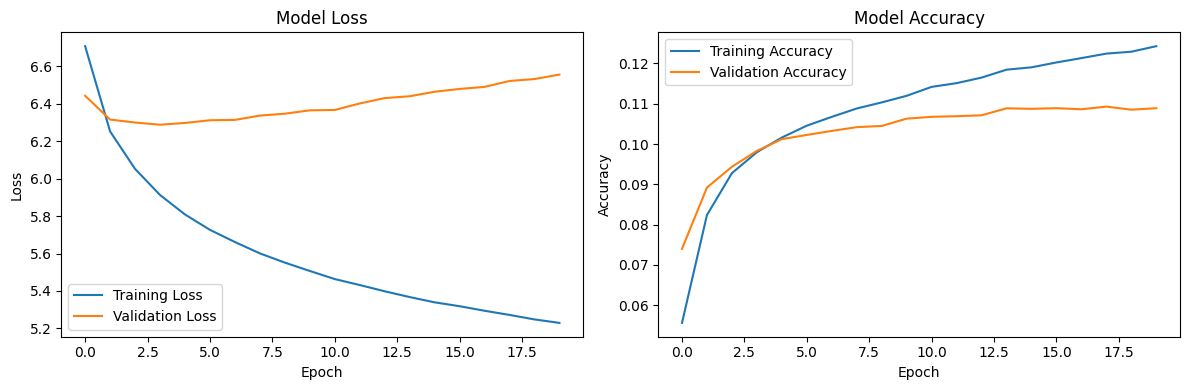


Training complete!


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

print("\nTraining complete!")